# Crop Health Model Training
## EfficientNet-B0 Transfer Learning for Disease Detection

This notebook trains a deep learning model to detect diseases in **Maize, Potato, and Tomato** leaves.

### Dataset Structure Required:
```
ml_research/data/
├── train/
│   ├── Maize_Healthy/
│   ├── Maize_Common_Rust/
│   ├── Potato_Late_Blight/
│   └── ...
└── val/
    └── ...
```

## Step 1: Import Libraries

In [1]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")


2026-04-19 21:59:21.113398: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.13.0
GPU available: []


In [2]:
# Paths
DATA_DIR = "../data"  # Relative to notebooks folder
MODEL_OUT = "../models/crop_health_model.h5"

# Hyperparameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS_HEAD = 10  # Train only top layers
EPOCHS_FINE = 10  # Fine-tune with unfrozen layers
NUM_CLASSES = 17  # 4 Maize + 3 Potato + 10 Tomato classes

print(f"Data directory: {DATA_DIR}")
print(f"Model will be saved to: {MODEL_OUT}")

Data directory: ../data
Model will be saved to: ../models/crop_health_model.h5


## Step 3: Load Dataset

In [3]:
print("Loading training data...")
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "train"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=42,
)

print("\nLoading validation data...")
val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "val"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False,
)

class_names = train_ds.class_names
print(f"\nFound {len(class_names)} classes:")
for i, name in enumerate(class_names):
    print(f"  {i}: {name}")

Loading training data...
Found 12068 files belonging to 17 classes.

Loading validation data...
Found 3020 files belonging to 17 classes.

Found 17 classes:
  0: Maize_Common_Rust
  1: Maize_Gray_Leaf_Spot
  2: Maize_Healthy
  3: Maize_Northern_Leaf_Blight
  4: Potato___Early_blight
  5: Potato___Late_blight
  6: Potato___healthy
  7: Tomato___Bacterial_spot
  8: Tomato___Early_blight
  9: Tomato___Late_blight
  10: Tomato___Leaf_Mold
  11: Tomato___Septoria_leaf_spot
  12: Tomato___Spider_mites_Two_spotted_spider_mite
  13: Tomato___Target_Spot
  14: Tomato___Tomato_Yellow_Leaf_Curl_Virus
  15: Tomato___Tomato_mosaic_virus
  16: Tomato___healthy


## Step 4: Data Augmentation & Preprocessing

In [4]:
# Data augmentation (only for training)
augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.1),
], name="augmentation")

def prepare(ds, augment=False):
    """Apply EfficientNet preprocessing and optional augmentation."""
    ds = ds.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        ds = ds.map(lambda x, y: (augmentation(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)
    return ds.prefetch(tf.data.AUTOTUNE)

train_ds = prepare(train_ds, augment=True)
val_ds = prepare(val_ds, augment=False)

print("Data augmentation applied to training set")

Data augmentation applied to training set


## Step 5: Visualize Sample Images

Matplotlib is building the font cache; this may take a moment.
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [6.562859..93.00399].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [23.996218..120.05874].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [7.3238015..123.48864].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [3.7916553..80.35419].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.5..102.30365].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [15.255983..105.96173].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats

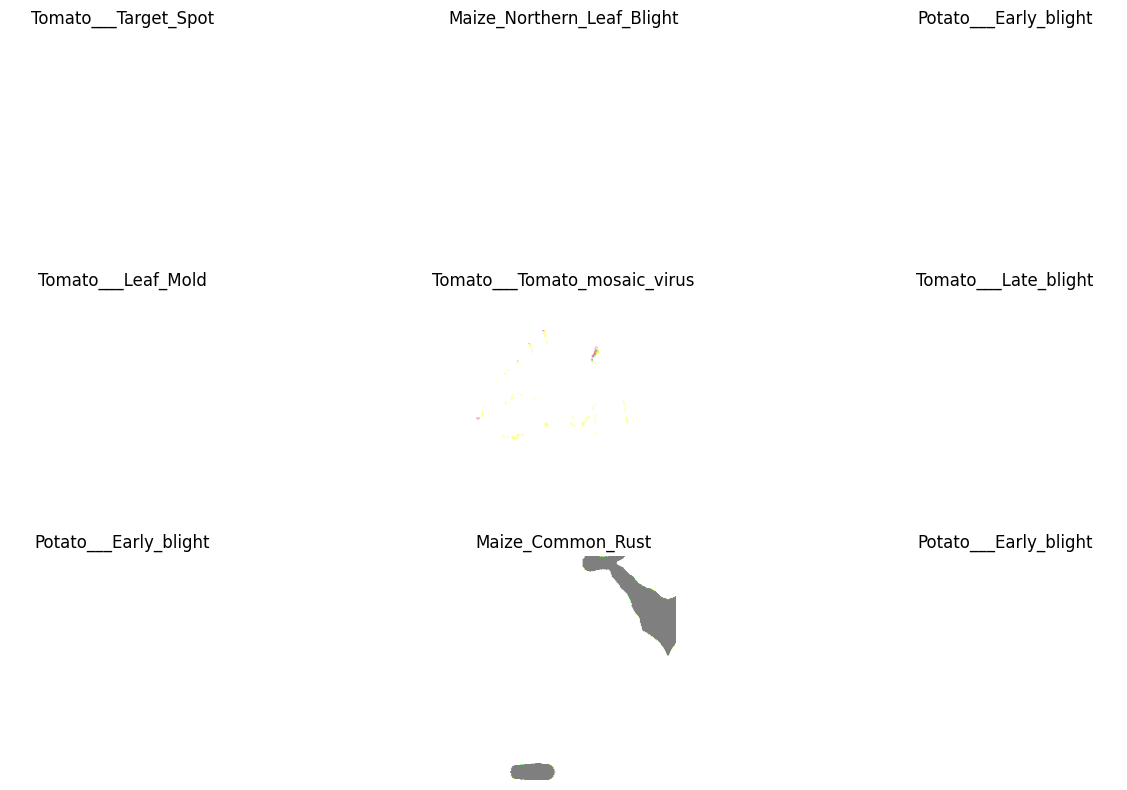

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Get a batch of images
for images, labels in train_ds.take(1):
    plt.figure(figsize=(15, 8))
    for i in range(min(9, len(images))):
        plt.subplot(3, 3, i + 1)
        # Denormalize image for display
        img = (images[i].numpy() + 1) / 2  # EfficientNet preprocessing scales to [-1, 1]
        plt.imshow(img)
        label_idx = np.argmax(labels[i])
        plt.title(class_names[label_idx])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

## Step 6: Build Model with EfficientNet-B0

In [6]:
print("Building model...")

# Load pre-trained EfficientNet-B0 (trained on ImageNet)
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(*IMG_SIZE, 3),
)
base_model.trainable = False  # Freeze base model initially

print(f"Base model layers: {len(base_model.layers)} (all frozen)")

# Add custom classification head
inputs = tf.keras.Input(shape=(*IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation="relu")(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = models.Model(inputs, outputs, name="crop_health_model")

model.summary()

Building model...
Base model layers: 238 (all frozen)
Model: "crop_health_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 efficientnetb0 (Functional  (None, 7, 7, 1280)        4049571   
 )                                                               
                                                                 
 global_average_pooling2d (  (None, 1280)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dropout (Dropout)           (None, 1280)              0         
                                                                 
 dense (Dense)               (None, 256)               327936    
                                                             

## Step 7: Train Top Layers Only (Phase 1)

In [7]:
print(f"Training top layers for {EPOCHS_HEAD} epochs...")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

# Callbacks
early_stop = callbacks.EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1)

history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD,
    callbacks=[early_stop, reduce_lr],
)

print("Phase 1 training complete!")

Training top layers for 10 epochs...
Epoch 1/10
378/378 [==============================] - 1003s 3s/step - loss: 0.6684 - accuracy: 0.7807 - val_loss: 0.4097 - val_accuracy: 0.8566 - lr: 0.0010
Epoch 2/10
378/378 [==============================] - 930s 2s/step - loss: 0.3726 - accuracy: 0.8691 - val_loss: 0.3584 - val_accuracy: 0.8642 - lr: 0.0010
Epoch 3/10
378/378 [==============================] - 929s 2s/step - loss: 0.3238 - accuracy: 0.8856 - val_loss: 0.3418 - val_accuracy: 0.8768 - lr: 0.0010
Epoch 4/10
378/378 [==============================] - 947s 3s/step - loss: 0.2981 - accuracy: 0.8932 - val_loss: 0.3135 - val_accuracy: 0.8868 - lr: 0.0010
Epoch 5/10
378/378 [==============================] - 926s 2s/step - loss: 0.2615 - accuracy: 0.9095 - val_loss: 0.2757 - val_accuracy: 0.8987 - lr: 0.0010
Epoch 6/10
378/378 [==============================] - 916s 2s/step - loss: 0.2522 - accuracy: 0.9080 - val_loss: 0.2910 - val_accuracy: 0.8964 - lr: 0.0010
Epoch 7/10
378/378 [======

## Step 8: Plot Training History (Phase 1)

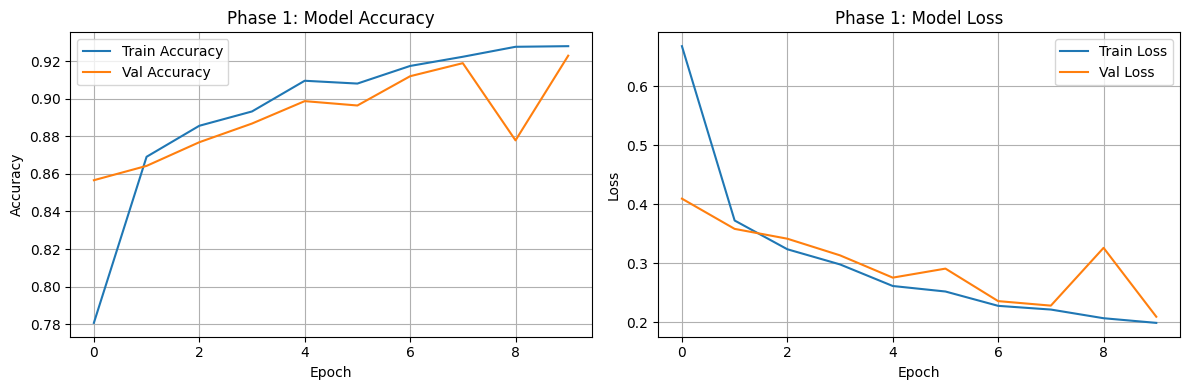

In [8]:
plt.figure(figsize=(12, 4))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_head.history['accuracy'], label='Train Accuracy')
plt.plot(history_head.history['val_accuracy'], label='Val Accuracy')
plt.title('Phase 1: Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(history_head.history['loss'], label='Train Loss')
plt.plot(history_head.history['val_loss'], label='Val Loss')
plt.title('Phase 1: Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Step 9: Fine-Tune Model (Phase 2)

In [9]:
print(f"Fine-tuning top 30 layers for {EPOCHS_FINE} more epochs...")

# Unfreeze top layers of base model
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

unfrozen = sum(1 for l in base_model.layers if l.trainable)
print(f"Unfrozen base layers: {unfrozen}")

# Recompile with lower learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINE,
    callbacks=[early_stop, reduce_lr],
)

print("Phase 2 fine-tuning complete!")

Fine-tuning top 30 layers for 10 more epochs...
Unfrozen base layers: 30
Epoch 1/10
378/378 [==============================] - 27886s 74s/step - loss: 0.1536 - accuracy: 0.9475 - val_loss: 0.2013 - val_accuracy: 0.9291 - lr: 1.0000e-05
Epoch 2/10
378/378 [==============================] - 1081s 3s/step - loss: 0.1323 - accuracy: 0.9527 - val_loss: 0.1947 - val_accuracy: 0.9281 - lr: 1.0000e-05
Epoch 3/10
378/378 [==============================] - 1074s 3s/step - loss: 0.1297 - accuracy: 0.9530 - val_loss: 0.1648 - val_accuracy: 0.9381 - lr: 1.0000e-05
Epoch 4/10
378/378 [==============================] - 1071s 3s/step - loss: 0.1241 - accuracy: 0.9562 - val_loss: 0.1756 - val_accuracy: 0.9377 - lr: 1.0000e-05
Epoch 5/10
378/378 [==============================] - ETA: 0s - loss: 0.1155 - accuracy: 0.9601
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
378/378 [==============================] - 1067s 3s/step - loss: 0.1155 - accuracy: 0.9601 - val_loss: 0.1669

## Step 10: Plot Training History (Phase 2)

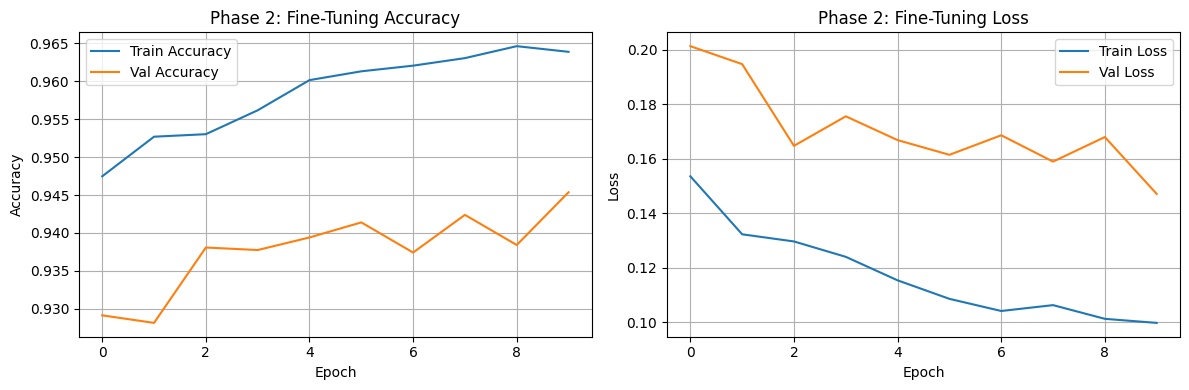

In [10]:
plt.figure(figsize=(12, 4))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_fine.history['accuracy'], label='Train Accuracy')
plt.plot(history_fine.history['val_accuracy'], label='Val Accuracy')
plt.title('Phase 2: Fine-Tuning Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(history_fine.history['loss'], label='Train Loss')
plt.plot(history_fine.history['val_loss'], label='Val Loss')
plt.title('Phase 2: Fine-Tuning Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Step 11: Save Model

In [11]:
print(f"Saving model to {MODEL_OUT}...")
os.makedirs(os.path.dirname(MODEL_OUT), exist_ok=True)
model.save(MODEL_OUT)
print(f"Model saved successfully!")

final_val_acc = max(history_fine.history.get("val_accuracy", [0]))
print(f"\nBest validation accuracy: {final_val_acc:.2%}")

Saving model to ../models/crop_health_model.h5...


/usr/local/lib/python3.11/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Model saved successfully!

Best validation accuracy: 94.54%


## Step 12: Evaluate Model

In [12]:
print("Evaluating model on validation set...")
loss, accuracy = model.evaluate(val_ds)
print(f"\nValidation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.2%}")

Evaluating model on validation set...
95/95 [==============================] - 186s 2s/step - loss: 0.1472 - accuracy: 0.9454

Validation Loss: 0.1472
Validation Accuracy: 94.54%


## Step 13: Test Predictions

1/1 [==============================] - 5s 5s/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.5..118.311066].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.5..128.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.5..127.7245].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.5..127.57907].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.5..122.553535].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.5..125.469406].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.5..122.28255].
Clipping input data to the valid ran

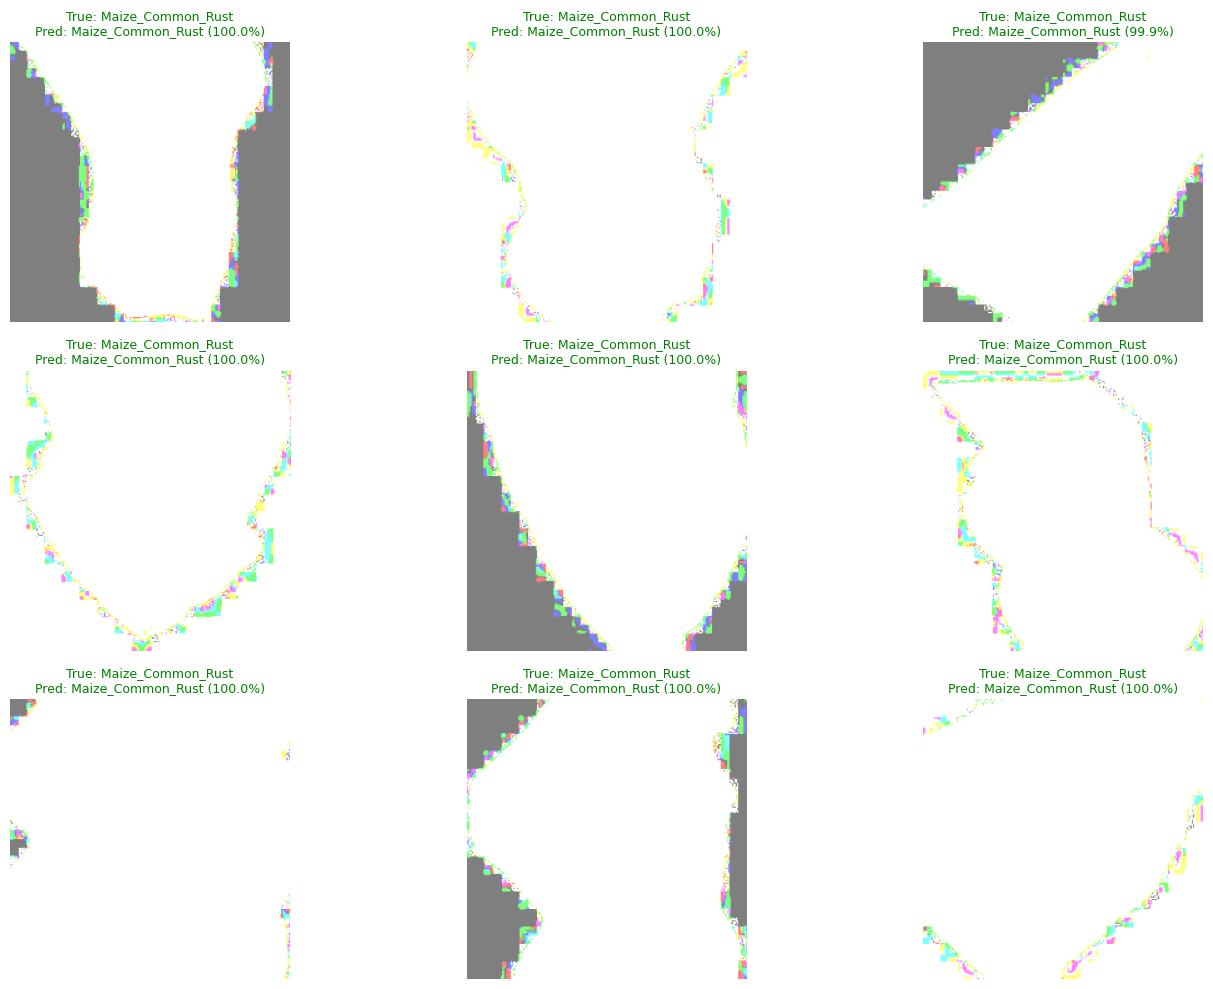

In [13]:
# Get a batch of validation images
for images, labels in val_ds.take(1):
    predictions = model.predict(images)
    
    plt.figure(figsize=(15, 10))
    for i in range(min(9, len(images))):
        plt.subplot(3, 3, i + 1)
        
        # Denormalize image
        img = (images[i].numpy() + 1) / 2
        plt.imshow(img)
        
        # Get true and predicted labels
        true_idx = np.argmax(labels[i])
        pred_idx = np.argmax(predictions[i])
        confidence = predictions[i][pred_idx]
        
        # Color: green if correct, red if wrong
        color = 'green' if true_idx == pred_idx else 'red'
        
        plt.title(f"True: {class_names[true_idx]}\nPred: {class_names[pred_idx]} ({confidence:.1%})", 
                  color=color, fontsize=9)
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    break

## Next Steps

1. Copy the trained model to backend:
   ```bash
   copy ..\models\crop_health_model.h5 ..\..\backend_new\models\
   ```

2. Update `backend_new/app/config.py` with the correct class names

3. Restart the backend server:
   ```bash
   cd backend_new
   uvicorn app.main:app --reload --port 8000
   ```

4. Test the API at http://localhost:3000